Loading data...
Data loaded and concatenated.


,match_pair,gameday,y
1844,横浜Ｆ・マリノス_アルビレックス新潟,2013-11-30,62632
942,浦和レッズ_セレッソ大阪,2013-12-07,54905
1463,浦和レッズ_セレッソ大阪,2014-05-17,54350
693,浦和レッズ_名古屋グランパス,2013-03-09,52293
270,浦和レッズ_名古屋グランパス,2012-12-01,51879
...,...,...,...
362,ザスパ草津_ギラヴァンツ北九州,2012-04-27,1447
625,ガイナーレ鳥取_ザスパ草津,2012-09-30,1363
452,ザスパ草津_ロアッソ熊本,2012-06-13,1333
1152,愛媛ＦＣ_ロアッソ熊本,2013-07-03,1104


,gameday,match_pair,actual,pred,error
372,2013-11-30,横浜Ｆ・マリノス_アルビレックス新潟,62632,37162.019644,25469.980356
290,2013-11-10,ベガルタ仙台_浦和レッズ,17183,40147.466942,22964.466942
381,2012-12-01,浦和レッズ_名古屋グランパス,51879,37005.320388,14873.679612
263,2013-11-03,ヴィッセル神戸_京都サンガF.C.,22468,8690.827443,13777.172557
184,2012-10-20,横浜Ｆ・マリノス_ジュビロ磐田,21310,34500.162081,13190.162081
361,2013-11-24,コンサドーレ札幌_ギラヴァンツ北九州,24813,12234.574474,12578.425526
319,2012-11-17,横浜Ｆ・マリノス_柏レイソル,22647,34900.289879,12253.289879
289,2013-11-10,大分トリニータ_アルビレックス新潟,8039,19549.967051,11510.967051
231,2013-10-27,名古屋グランパス_大宮アルディージャ,14016,25266.046524,11250.046524
382,2013-12-07,浦和レッズ_セレッソ大阪,54905,43926.418340,10978.581660


,gameday,match_pair,y,error,home,away,weather,capa
13,2013-11-30,横浜Ｆ・マリノス_アルビレックス新潟,62632,25469.980356,横浜Ｆ・マリノス,アルビレックス新潟,晴,72327
3,2013-11-10,ベガルタ仙台_浦和レッズ,17183,22964.466942,ベガルタ仙台,浦和レッズ,晴,49133
17,2012-12-01,浦和レッズ_名古屋グランパス,51879,14873.679612,浦和レッズ,名古屋グランパス,晴,63700
6,2013-11-03,ヴィッセル神戸_京都サンガF.C.,22468,13777.172557,ヴィッセル神戸,京都サンガF.C.,屋内,30132
14,2012-10-20,横浜Ｆ・マリノス_ジュビロ磐田,21310,13190.162081,横浜Ｆ・マリノス,ジュビロ磐田,晴,72327
0,2013-11-24,コンサドーレ札幌_ギラヴァンツ北九州,24813,12578.425526,コンサドーレ札幌,ギラヴァンツ北九州,屋内,39232
15,2012-11-17,横浜Ｆ・マリノス_柏レイソル,22647,12253.289879,横浜Ｆ・マリノス,柏レイソル,雨,72327
9,2013-11-10,大分トリニータ_アルビレックス新潟,8039,11510.967051,大分トリニータ,アルビレックス新潟,曇時々雨のち晴,40000
8,2013-10-27,名古屋グランパス_大宮アルディージャ,14016,11250.046524,名古屋グランパス,大宮アルディージャ,晴,40000
16,2013-12-07,浦和レッズ_セレッソ大阪,54905,10978.581660,浦和レッズ,セレッソ大阪,晴,63700


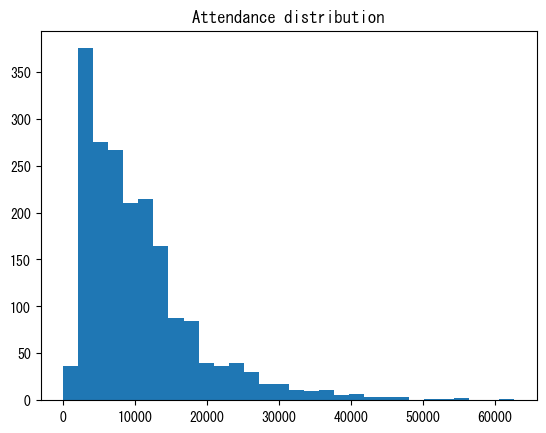

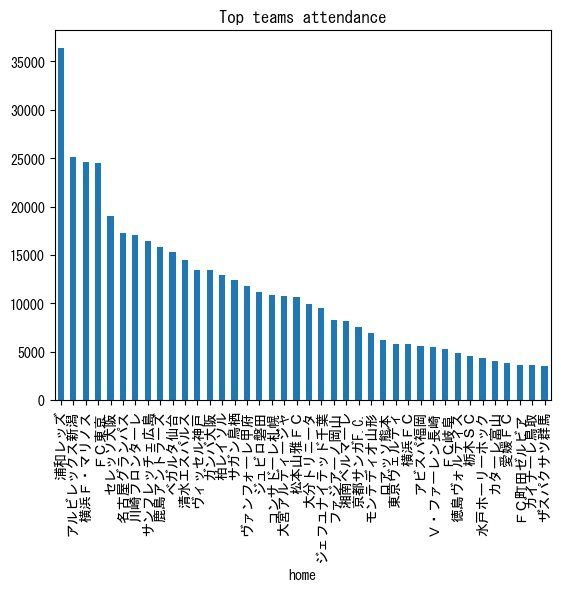

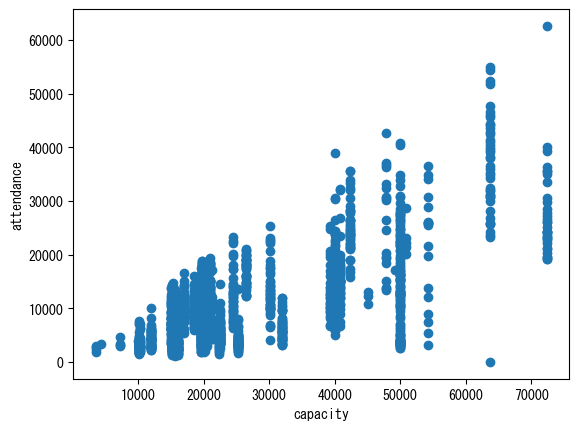

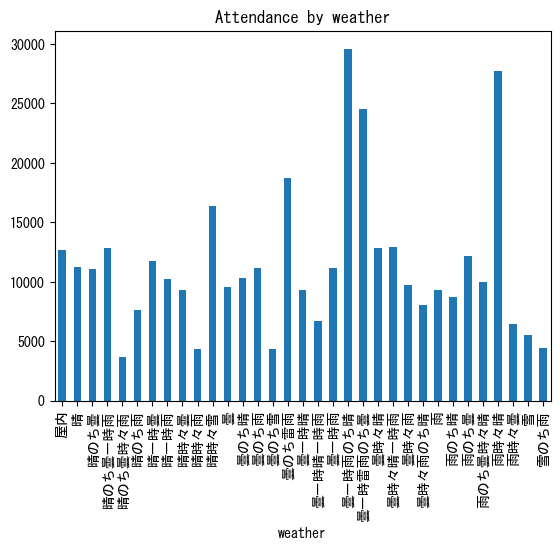

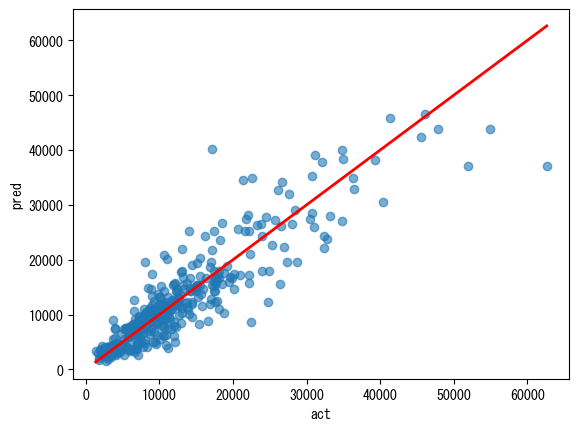

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from src.load_data import load_data
from src.features import create_features
from config import FEATURES, TARGET
import matplotlib.pyplot as plt
data_path = "data"
df = pd.read_csv(os.path.join(data_path,"valid_result.csv"))
df["gameday"] = pd.to_datetime(df["gameday"])
data_path="data"
plt.rcParams["font.family"] = "MS Gothic"

train, test = load_data()


train = create_features(train)

display(train[["match_pair","gameday","y"]] .sort_values("y", ascending=False))

error_df = df.copy()
error_df["error"] = abs(df["actual"] - df["pred"])
top_error = error_df.sort_values("error", ascending=False).head(20)
display(top_error)



error_games = train.merge(
    top_error[["gameday","match_pair","error"]],
    on=["gameday","match_pair"],
    how="inner")

display(
    error_games[
        ["gameday","match_pair","y","error","home","away","weather","capa"]
    ].sort_values("error", ascending=False))


plt.hist(train["y"], bins=30)
plt.title("Attendance distribution")
plt.show()


team_rank = train.groupby("home")["y"].mean().sort_values(ascending=False)
team_rank.head(40).plot(kind="bar")
plt.title("Top teams attendance")
plt.show()


plt.scatter(train["capa"], train["y"])
plt.xlabel("capacity")
plt.ylabel("attendance")
plt.show()

train.groupby("weather")["y"].mean().plot(kind="bar")
plt.title("Attendance by weather")
plt.show()




plt.scatter(df["actual"], df["pred"], alpha=0.6)
plt.xlabel("act")
plt.ylabel("pred")

# 理想線
plt.plot(
    [df["actual"].min(), df["actual"].max()],
    [df["actual"].min(), df["actual"].max()],
    color="red",
    linewidth=2
)

plt.show()

